## Capstone Project

# Smart Resume Screener & Job Recommendation Portal

**AIM:**


To build an intelligent and user-friendly web application
that automatically analyzes uploaded resumes using NLP-driven Machine Learning
models and identifies the most suitable job roles for each candidate. Along with
predicting role fit, the system recommends relevant job openings from the
database and highlights key strengths and skill gaps, helping users improve their
career readiness.

This dual-purpose platform not only assists HR professionals by automating the
initial screening process but also empowers job seekers with personalized career
insights, making the hiring process smarter, faster, and more effective for both
sides.

**Import libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

**Load dataset**

In [2]:
df = pd.read_csv("job_roles.csv")
df.head()

,Job Title,Category,Education Requirement,Experience Years,Required Skills,Salary Range
0,Software Engineer,Technology,Bachelor's in Computer Science|Bachelor's in E...,2,Python|Java|C++|Git|Software Design|Problem So...,80-150K
1,Full Stack Developer,Technology,Diploma in IT|Bachelor's in Computer Science,2,JavaScript|React|Node.js|HTML/CSS|Database|Git,75-140K
2,Frontend Developer,Technology,Diploma in IT|Bachelor's in Computer Science,1,JavaScript|React|Vue.js|CSS|HTML|UI/UX Design,70-130K
3,Backend Developer,Technology,Bachelor's in Computer Science,2,Python|Java|Node.js|Database Design|API Develo...,75-135K
4,DevOps Engineer,Technology,Bachelor's in Computer Science|IT Certification,3,Docker|Kubernetes|AWS|Linux|CI/CD|Scripting,85-150K


In [3]:
df.tail()

,Job Title,Category,Education Requirement,Experience Years,Required Skills,Salary Range
319,Museum Curator,Arts & Culture,Master's in Art History|Museum Studies,3,Curation|Art Knowledge|Research|Communication|...,55-100K
320,Conservator,Arts & Culture,Master's in Conservation,2,Conservation|Restoration|Technical Skills|Prec...,55-100K
321,Exhibition Designer,Arts & Culture,Bachelor's in Design|Museum Studies,2,Exhibition Design|Creativity|Technical Skills|...,50-90K
322,Veterinarian,Veterinary,Doctor of Veterinary Medicine,1,Veterinary Medicine|Animal Care|Diagnosis|Comm...,80-150K
323,Veterinary Technician,Veterinary,Associate in Veterinary Technology,1,Veterinary Care|Animal Handling|Technical Skil...,35-60K


**Understand the data**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Job Title              324 non-null    str  
 1   Category               324 non-null    str  
 2   Education Requirement  324 non-null    str  
 3   Experience Years       324 non-null    int64
 4   Required Skills        324 non-null    str  
 5   Salary Range           324 non-null    str  
dtypes: int64(1), str(5)
memory usage: 64.9 KB


In [4]:
df.shape

(324, 6)

In [6]:
df.describe()

,Experience Years
count,324.000000
mean,2.120370
std,1.733217
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,10.000000


### Observation: Descriptive Statistics Analysis

- The dataset contains 324 records,8 features.
- The presence of a few highly experienced candidates (up to 10 years) may introduce outliers but provides some representation of senior profiles.
- The average experience of candidates is approximately 2.12 years, indicating that most candidates are early-career professionals.
- The average resume text length is approximately 80.87 words/units.

In [38]:
df.describe(include='O').T

C:\Users\user\AppData\Local\Temp\ipykernel_21976\800431826.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O').T


,count,unique,top,freq
Job Title,324,324,Software Engineer,1
Category,324,38,Technology,82
Education Requirement,324,245,Bachelor's in Computer Science,38
Required Skills,324,324,Python|Java|C++|Git|Software Design|Problem So...,1
Salary Range,324,90,70-130K,33
Job_Text,324,324,Software Engineer Technology Python|Java|C++|G...,1


**Data cleaning**

In [8]:
#Check Missing Values
df.isnull().sum()   #if get missing val,then  df.dropna(inplace=True)

Job Title                0
Category                 0
Education Requirement    0
Experience Years         0
Required Skills          0
Salary Range             0
dtype: int64

In [9]:
#Check Duplicate Resumes
df.duplicated().sum()  #if get duplicate val,then df.drop_duplicates(inplace=True)

np.int64(0)

In [10]:
df['Job Title'].value_counts()

Job Title
Software Engineer        1
Full Stack Developer     1
Frontend Developer       1
Backend Developer        1
DevOps Engineer          1
                        ..
Museum Curator           1
Conservator              1
Exhibition Designer      1
Veterinarian             1
Veterinary Technician    1
Name: count, Length: 324, dtype: int64

### observation-Data cleaning

- There is no missing values
- There is no dulpicate data

## Visualization

**Job Roles Distribution**

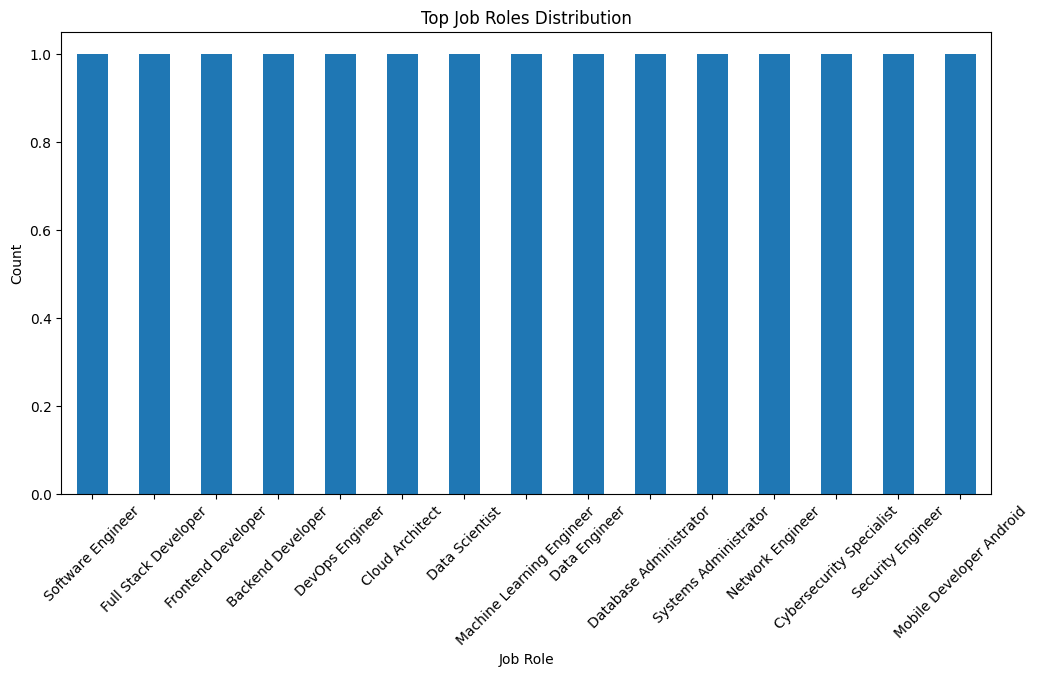

In [11]:
plt.figure(figsize=(12,6))
df['Job Title'].value_counts().head(15).plot(kind='bar')
plt.title("Top Job Roles Distribution")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Observation: Top Job Roles Distribution

- This graph shows the distribution of different job roles in the dataset.
  - X-axis: Job Roles (Job Titles)
  - Y-axis: Count (number of records for each role)
- All displayed job roles have equal frequency.Every job role has a count of 1.
- This means each role appears only once in the dataset.

**Job Category Distribution**

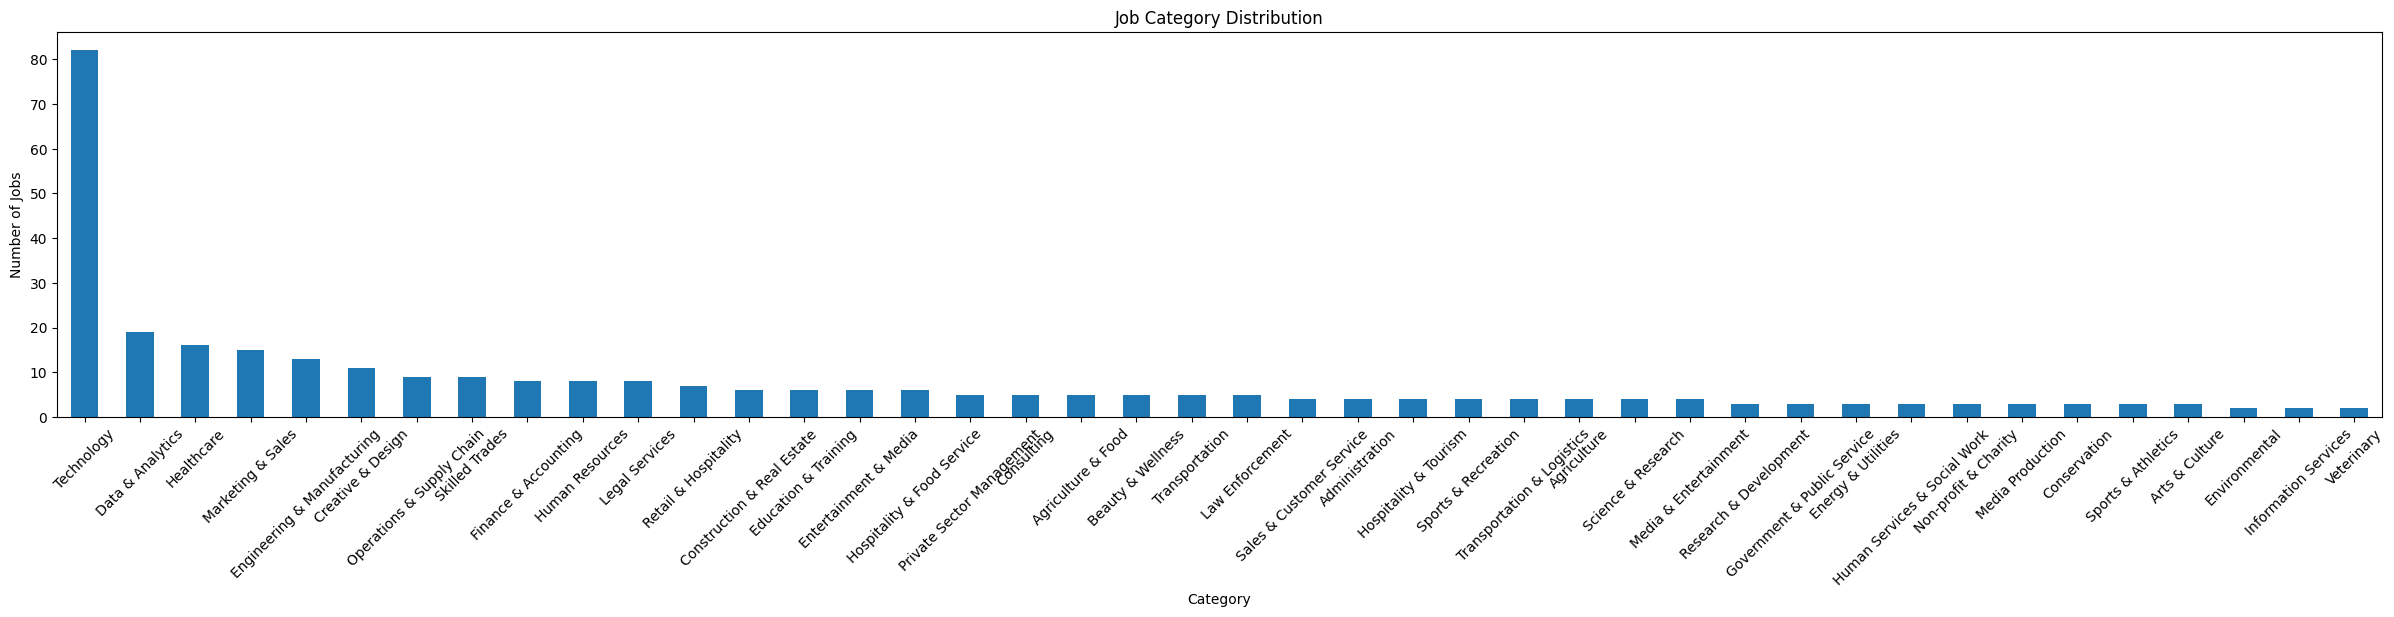

In [12]:
plt.figure(figsize=(30,5))
df['Category'].value_counts().plot(kind='bar')
plt.title("Job Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

### Observation: Job Category Distribution

- This graph represents the distribution of job categories in the dataset.
  - X-axis: Job Categories
  - Y-axis: Number of Jobs (count of records)
- Technology category has the highest number of jobs.The Technology category has the largest count (around 80+ jobs).
- This indicates that the dataset contains more technology-related job opportunities compared to other fields.

**Experience Years Distribution**

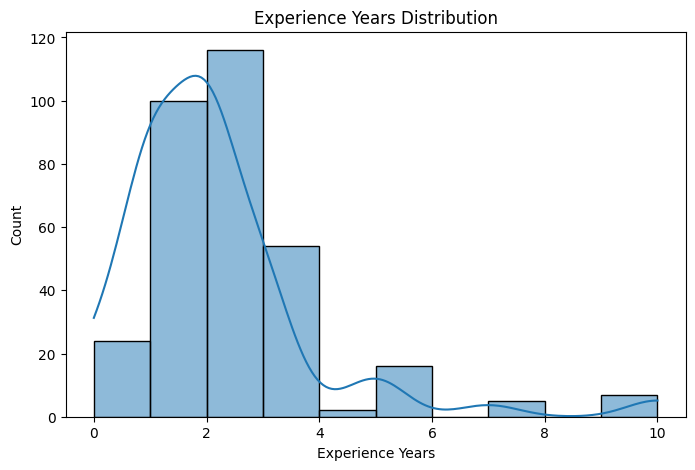

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Experience Years'],bins=10,kde=True)
plt.title("Experience Years Distribution")

plt.show()

### Observation: Experience Years Distribution

- Candidates with 2–3 years of experience form the largest group
- Very few candidates have 7–10 years of experience, indicating limited representation of senior-level candidates.
- The distribution is right-skewed (positively skewed) because most values are concentrated on the lower experience range, with a long tail toward     higher experience years.
- This suggests the dataset is more suitable for predicting entry-level and mid-level job categories rather than senior positions.


In [5]:
from collections import Counter

skills = " ".join(df['Required Skills'])
words = skills.split()
word_count = Counter(words)
common_words = word_count.most_common(15)
pd.DataFrame(common_words,columns=['Skill','Frequency'])

,Skill,Frequency
0,Solving,41
1,to,22
2,Detail,13
3,Skills,13
4,Knowledge,12
5,Management,11
6,Knowledge|Problem,11
7,Design,10
8,Strategic,10
9,Development,10


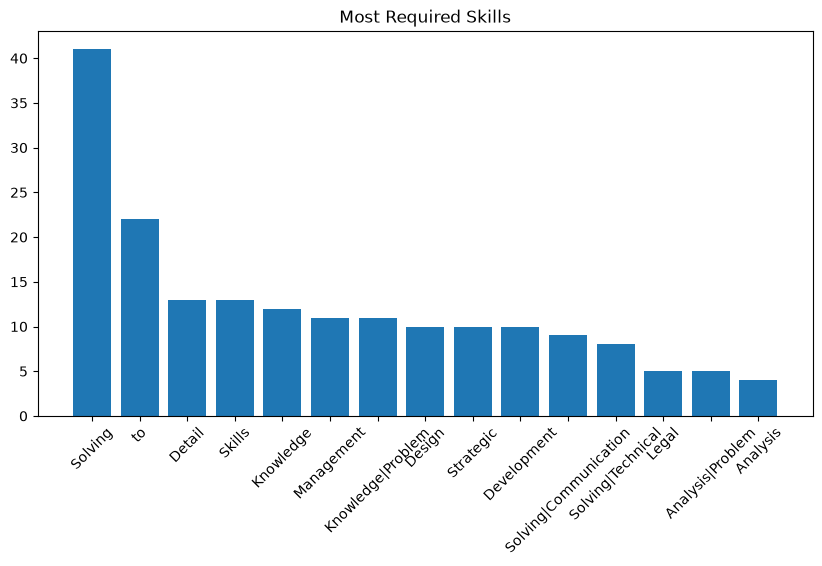

In [6]:
skill_df = pd.DataFrame(common_words,columns=['Skill','Frequency'])
plt.figure(figsize=(10,5))
plt.bar(skill_df['Skill'],skill_df['Frequency'])
plt.title("Most Required Skills")
plt.xticks(rotation=45)

plt.show()

**combine columns**

In [7]:
df['Job_Text'] = (df['Job Title'] + " " +df['Category'] + " " +df['Required Skills'])
df[['Job_Text','Job Title']].head()

,Job_Text,Job Title
0,Software Engineer Technology Python|Java|C++|G...,Software Engineer
1,Full Stack Developer Technology JavaScript|Rea...,Full Stack Developer
2,Frontend Developer Technology JavaScript|React...,Frontend Developer
3,Backend Developer Technology Python|Java|Node....,Backend Developer
4,DevOps Engineer Technology Docker|Kubernetes|A...,DevOps Engineer


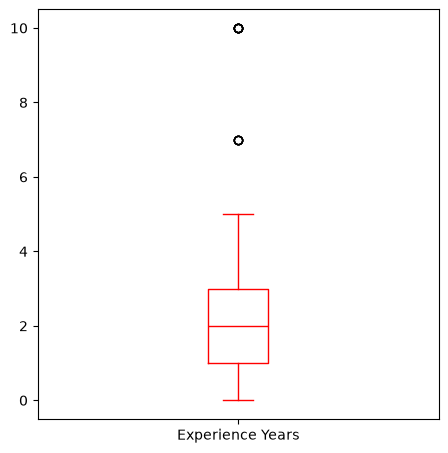

In [8]:
df.plot(kind='box',subplots=True,layout=(8,5),figsize=(30,50),color='red')
plt.title('boxplots of data set features')
plt.show()

### Boxplot Analysis (Experience Years & Text Length)

1. Experience Years

- The boxplot shows that most candidates have experience values between approximately 1 and 3 years.
- The median experience is around 2 years, indicating that the dataset mainly contains early-career candidates.
- The range extends from 0 to 5 years for most data points.
- There are some outliers at 7 and 10 years, representing candidates with significantly higher experience compared to the majority.
- The presence of these outliers indicates fewer senior-level candidates in the dataset.

2. Resume Text Length
   
- Resume text length is mostly concentrated between approximately 75 and 90 words/units.
- The median text length is around 82, showing that most resumes have similar content sizes.
- Some resumes have shorter text lengths (around 40–50), appearing as lower outliers.
- A few resumes have very long text lengths (above 120), appearing as upper outliers.
- The variation suggests differences in resume detail levels among candidates.
- The outliers may represent resumes with either incomplete information or highly detailed professional profiles.


# FEATURE ENGINEERING

## TF-IDF Conversion

- Resume and job description text data cannot be directly given to the ML model. 
- Text features are converted into numerical form using TF-IDF (Term Frequency–Inverse Document Frequency).

## Merging duplicate category labels

Several categories in the raw data are the same real-world category written two different ways.
We merge only the exact duplicates agreed on so far - the broader "group rare categories together"
step is still pending a team decision, so it isn't applied here.

In [9]:
# Map duplicate labels onto a single, consistent name.
# Only exact-duplicate pairs are merged here - nothing else is touched.
category_merge_map = {
    "Transportation": "Transportation & Logistics",
    "Media & Entertainment": "Entertainment & Media",
    "Hospitality & Tourism": "Hospitality & Food Service",
    "Retail & Hospitality": "Hospitality & Food Service",
}

df['Category'] = df['Category'].replace(category_merge_map)

# Sanity check - confirms the duplicate labels are gone and shows the updated counts
df['Category'].value_counts()

Category
Technology                      82
Data & Analytics                19
Hospitality & Food Service      17
Healthcare                      16
Marketing & Sales               15
Engineering & Manufacturing     13
Creative & Design               11
Entertainment & Media           10
Operations & Supply Chain        9
Transportation & Logistics       9
Skilled Trades                   9
Finance & Accounting             8
Human Resources                  8
Legal Services                   8
Construction & Real Estate       6
Education & Training             6
Private Sector Management        5
Consulting                       5
Agriculture & Food               5
Beauty & Wellness                5
Law Enforcement                  5
Sales & Customer Service         4
Administration                   4
Sports & Recreation              4
Agriculture                      4
Science & Research               4
Research & Development           3
Government & Public Service      3
Energy & Ut

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df['Job_Text']
y = df['Category']

tfidf = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_features=20000)

X_vector = tfidf.fit_transform(X)

In [11]:
print(X_vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7511 stored elements and shape (324, 3314)>
  Coords	Values
  (0, 2651)	0.4083507674274557
  (0, 1034)	0.1637045881016427
  (0, 2941)	0.11273667701682508
  (0, 2237)	0.1972499204213814
  (0, 1410)	0.22197167618590044
  (0, 1231)	0.2751397699869157
  (0, 830)	0.14095844070796096
  (0, 2147)	0.09127355369311169
  (0, 2669)	0.09127355369311169
  (0, 2657)	0.2947625314681922
  (0, 1040)	0.20417538371372784
  (0, 2983)	0.22767186682871485
  (0, 2244)	0.2751397699869157
  (0, 1413)	0.2947625314681922
  (0, 1232)	0.2947625314681922
  (0, 2656)	0.2947625314681922
  (0, 856)	0.26121719914845354
  (0, 2148)	0.09127355369311169
  (1, 2941)	0.09983949128203314
  (1, 1231)	0.24366351212258644
  (1, 2766)	0.2610414105641641
  (1, 879)	0.1205857037488274
  (1, 1419)	0.1808175208078045
  (1, 2281)	0.23133369695832823
  (1, 1911)	0.23133369695832823
  :	:
  (322, 407)	0.24009033953832512
  (322, 917)	0.24009033953832512
  (322, 534)	0.224107

## Checking class balance before splitting

In [12]:
# How many job postings does each category have?
# This matters because a category with very few rows is hard to
# split fairly between train and test, and hard for a model to learn.
df['Category'].value_counts()

Category
Technology                      82
Data & Analytics                19
Hospitality & Food Service      17
Healthcare                      16
Marketing & Sales               15
Engineering & Manufacturing     13
Creative & Design               11
Entertainment & Media           10
Operations & Supply Chain        9
Transportation & Logistics       9
Skilled Trades                   9
Finance & Accounting             8
Human Resources                  8
Legal Services                   8
Construction & Real Estate       6
Education & Training             6
Private Sector Management        5
Consulting                       5
Agriculture & Food               5
Beauty & Wellness                5
Law Enforcement                  5
Sales & Customer Service         4
Administration                   4
Sports & Recreation              4
Agriculture                      4
Science & Research               4
Research & Development           3
Government & Public Service      3
Energy & Ut

### Observation: Class balance

- The exact-duplicate labels have already been merged above, so the counts here reflect the cleaned-up categories.
- Even after merging, a number of categories still have very few rows (1-4) - these are genuinely rare categories, not labeling duplicates, and scored 0.00 precision/recall/F1 in the earlier report because the model barely saw any examples of them.
- Whether to further group these rare categories together (e.g. into an "Other" bucket) is still pending a team decision, so they're left as-is for now.
- We handle the split fairly below by stratifying, so every remaining category is represented proportionally in both train and test.

## Train-Test Split

In [13]:
# Split into train and test sets.
# We use stratify=y so every category keeps the same proportion in
# both the train set and the test set. This matters a lot here because
# some categories have very few rows (see the class balance check above).
# If a category has fewer than 2 rows, stratify isn't possible, so we fall
# back to a plain random split in that case.

smallest_class_size = df['Category'].value_counts().min()

if smallest_class_size >= 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X_vector, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Used a stratified split - every category is represented fairly in train and test.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_vector, y, test_size=0.2, random_state=42
    )
    print("Could not stratify - at least one category has only 1 row. Used a plain random split instead.")

Used a stratified split - every category is represented fairly in train and test.


## Model selection

As required for Ticket 2, we train **multiple algorithms** on the same train/test split and compare
them, instead of committing to one model up front:

- **KNN** - resume/job screening is fundamentally a similarity problem, so KNN (nearest neighbours in TF-IDF space) is a natural baseline. It also naturally supports "find similar resumes/jobs" for the recommendation feature later.
- **Logistic Regression** - a strong, fast linear baseline for text classification, often very competitive with TF-IDF features.
- **Random Forest** - a tree-based model that can pick up non-linear patterns in the skill/keyword combinations.

We use `class_weight='balanced'` where available, so the rare categories (Agriculture, Transportation & Logistics) aren't just ignored in favor of the bigger categories.

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
}

results = {}
predictions = {}

for name, model in models.items():
    # IMPORTANT: fit on X_train/y_train only - never on the full X_vector/y.
    # Fitting on the full data (including the test rows) was the earlier bug -
    # it let the model "see" the test answers during training, which is why
    # the old accuracy (94%) was inflated and not trustworthy.
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    results[name] = acc
    predictions[name] = pred
    print(f"{name} accuracy: {acc:.4f}")

KNN accuracy: 0.8923
Logistic Regression accuracy: 0.9231
Random Forest accuracy: 0.9692


## Model comparison

                 Model  Accuracy
2        Random Forest  0.969231
1  Logistic Regression  0.923077
0                  KNN  0.892308


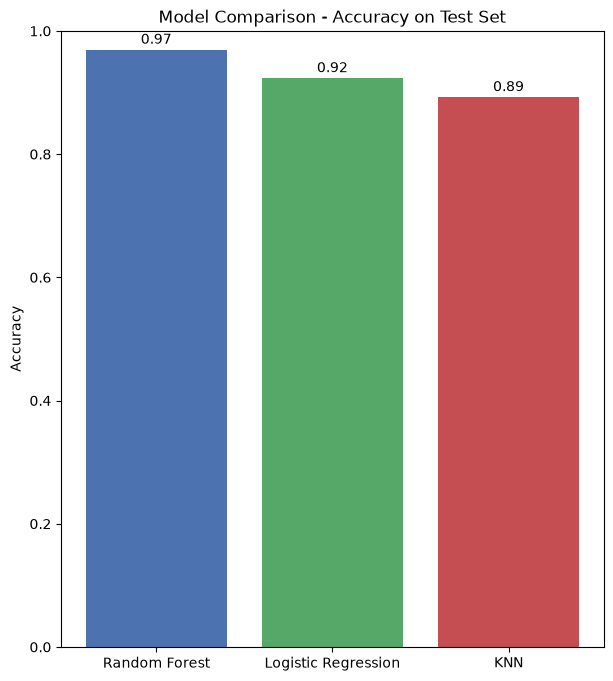

Best model: Random Forest


In [27]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)
print(results_df)

plt.figure(figsize=(7,8))
plt.bar(results_df['Model'], results_df['Accuracy'], color=['#4C72B0','#55A868','#C44E52'])
plt.title("Model Comparison - Accuracy on Test Set")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, acc in enumerate(results_df['Accuracy']):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center')
plt.show()

best_model_name = results_df.iloc[0]['Model']
print("Best model:", best_model_name)

## Detailed evaluation of the best model

In [37]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9692307692307692


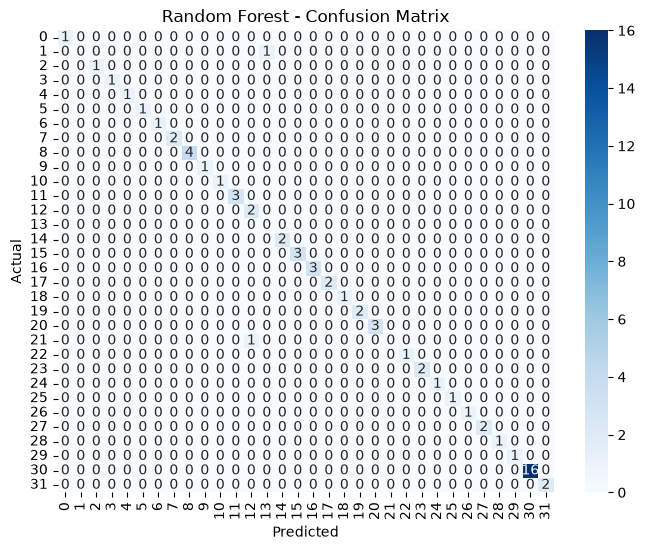

In [23]:
best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()

In [24]:
report = classification_report(y_test, best_pred, zero_division=0)
print(f"Classification Report - {best_model_name}:")
print(report)

Classification Report - Random Forest:
                             precision    recall  f1-score   support

             Administration       1.00      1.00      1.00         1
                Agriculture       0.00      0.00      0.00         1
         Agriculture & Food       1.00      1.00      1.00         1
          Beauty & Wellness       1.00      1.00      1.00         1
               Conservation       1.00      1.00      1.00         1
 Construction & Real Estate       1.00      1.00      1.00         1
                 Consulting       1.00      1.00      1.00         1
          Creative & Design       1.00      1.00      1.00         2
           Data & Analytics       1.00      1.00      1.00         4
       Education & Training       1.00      1.00      1.00         1
         Energy & Utilities       1.00      1.00      1.00         1
Engineering & Manufacturing       1.00      1.00      1.00         3
      Entertainment & Media       0.67      1.00      0.80     

## Observation

- The Random Forest classifier achieved an overall accuracy of 97%, indicating excellent performance in predicting job categories from the resume dataset.
- Excellent Performance: Most categories such as Technology, Data & Analytics, Healthcare, Marketing & Sales, Human Resources, Legal Services, Hospitality & Food Service, Engineering & Manufacturing, and Finance & Accounting achieved 100% precision, recall, and F1-score, indicating perfect classification.
- Technology Category: This category had the highest number of test samples (16) and was classified perfectly, demonstrating the model's robustness on the largest class.
- Minor Misclassifications: Categories like Entertainment & Media obtained a precision of 0.67 but a recall of 1.00, suggesting that although all actual instances were correctly identified, a few resumes from other categories were incorrectly predicted as Entertainment & Media.
Poorly Performing Categories: The Agriculture and Media Production categories received precision, recall, and F1-scores of 0.00 because the model failed to correctly classify their single test instances.
- Environmental Category: This category has a support value of 0, meaning there were no test samples belonging to this class. Therefore, its performance metrics are not meaningful and can be ignored.

**model saving**

In [36]:
import os
import pickle

path = r"D:\capstone_project"

# create folder if not exists
os.makedirs(path, exist_ok=True)

# save Random forest model
pickle.dump(rf_model,open(os.path.join(path,"resume_model.pkl"),"wb"))
# save TF-IDF
pickle.dump(tfidf,open(os.path.join(path,"tfidf_vectorizer.pkl"),"wb"))
print("Models saved successfully")

Models saved successfully
